In [ ]:
import requests, json, time, pandas as pd, pytz, yfinance as yf, numpy as np
from datetime import datetime as dt, timedelta, timezone, date
from concurrent.futures import ThreadPoolExecutor

class Orderbook:
    def __init__(self, days_back=7, max_workers=10, start_day_from_now=0, intraday_minutes=15):
        self.days_back = days_back
        self.start_day_from_now = start_day_from_now
        self.intraday_minutes = intraday_minutes
        self.max_workers = max_workers
        self.gamma_api = "https://gamma-api.polymarket.com/events/slug"
        self.goldsky_url = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/orderbook-subgraph/0.0.1/gn"
        self.timezone_map = {
            'new york': 'America/New_York',
            'london': 'Europe/London',
            'tokyo': 'Asia/Tokyo',
            'europe': 'Europe/Berlin'}
        self.asset_keys = []
        self.df = pd.DataFrame()
        self.orderbook = pd.DataFrame()

    def get_data(self, keys):
        self._get_multiple_tokens(keys)
        self._process_all_orderfills()

        def get_outcome_date(row): #to get the right match
            base_date = row['TIMESTAMP'].astimezone(pytz.timezone(self.timezone_map.get(row['country'].lower(), 'UTC'))).date()
            return base_date + timedelta(days=1) if 0 <= row['REL_HOUR'] < 8 else base_date

        self.orderbook['market_date'] = self.orderbook.apply(get_outcome_date, axis=1)
        stock_df = self._pull_stock_close()
        self.orderbook = self.orderbook.merge(
            stock_df,
            left_on=['KEY', 'market_date'],
            right_on=['KEY', 'date'], how='left')
        self.orderbook['TIMESTAMP'] = pd.to_datetime(self.orderbook['TIMESTAMP'])
        self.orderbook = self.orderbook.sort_values('TIMESTAMP')
        time_window_stock_pull = self.intraday_minutes #add 30 min too for robustness
        stock_min = self._pull_stock_minutes(minutes=time_window_stock_pull, window_size=120//time_window_stock_pull) #the window size determines std for BS: use past 120mins
        stock_min['TIMESTAMP'] = pd.to_datetime(stock_min['TIMESTAMP'])
        stock_min = stock_min.sort_values('TIMESTAMP')
        self.orderbook = pd.merge_asof(
            self.orderbook,
            stock_min,
            on='TIMESTAMP',
            by='KEY',
            direction='backward',
            tolerance=pd.Timedelta(f'{str(time_window_stock_pull)}min'))
        self.orderbook = self.orderbook.drop(columns=['date', 'market_date']).reset_index(drop=True)
        self.orderbook = self.orderbook.sort_values(by=['KEY', 'TIMESTAMP'], ascending=[True, True])
        return self.orderbook

    def _get_market_tokens(self, key_tuple):
        key = key_tuple[0]; country = key_tuple[1].lower()
        local_timezone = pytz.timezone(self.timezone_map.get(country, 'UTC'))
        now_local = dt.now(local_timezone) - timedelta(days=self.start_day_from_now)
        data = []
        for i in range(self.days_back):
            target = now_local - timedelta(days=i)
            slug = f"{key}-up-or-down-on-{target.strftime('%B-%-d-%Y').lower()}"
            try:
                r = requests.get(f"{self.gamma_api}/{slug}")
                if r.status_code == 200:
                    res_json = r.json()
                    if res_json.get("markets"):
                        m = res_json["markets"][0]
                        condition_id = m.get('conditionId')
                        tks = json.loads(m.get('clobTokenIds', '[]'))
                        data.append([key.upper(), target.date(), tks[0], tks[1], condition_id, country])
            except Exception as e:
                print(f"error fetching {slug}: {e}")
        #print(condition_id, tks[0], tks[1], target) #to get token - date to manually test on graphiQL
        return pd.DataFrame(data, columns=['key', 'ts', 'up_token', 'down_token', 'condition_id', 'country'])

    def _get_multiple_tokens(self, keys):
        all_dfs = []
        for k in keys:
            asset_name = k[0] if isinstance(k, tuple) else k
            self.asset_keys.append(asset_name.upper())
            print(f"--- collecting & processing: {asset_name.upper()} ---")
            raw = self._get_market_tokens(k if isinstance(k, tuple) else (k, 'new york'))
            all_dfs.append(raw)

        if not all_dfs: return pd.DataFrame()
        self.df = pd.concat(all_dfs).sort_values(['ts', 'key']).reset_index(drop=True)
        return self.df

    def _get_single_orderfills(self, a, start_dt, end_dt, up_down_key):
        q = '''query($a: String!, $g: BigInt!, $l: BigInt!) {
            orderFilledEvents(
              where: {
                or: [
                  {
                    timestamp_gte: $g,
                    timestamp_lte: $l,
                    takerAssetId: $a,
                    makerAssetId: "0"
                  },
                  {
                    timestamp_gte: $g,
                    timestamp_lte: $l,
                    makerAssetId: $a,
                    takerAssetId: "0"
                  }
                ]
              }
              orderBy: timestamp
              orderDirection: desc
            ) {
              id
              timestamp
              maker
              taker
              takerAssetId
              makerAssetId
              makerAmountFilled
              takerAmountFilled
            }
        }'''
        ts_g = int(start_dt.timestamp())
        ts_l = int(end_dt.timestamp())
        try:
            r = requests.post(self.goldsky_url, json={'query': q, 'variables': {'a': a, 'g': str(ts_g), 'l': str(ts_l)}}, timeout=15)
            if r.status_code != 200 or 'data' not in r.json(): return pd.DataFrame()
            events = r.json()['data']['orderFilledEvents']
            if not events: return pd.DataFrame()
            data = []
            for e in events:
                buy_shares = 'BUY' if str(e['takerAssetId']) == "0" else "SELL"
                m, t = int(e['makerAmountFilled'])/1e6, int(e['takerAmountFilled'])/1e6
                price = (t/m if e['takerAssetId'] == '0' else m/t) if m != 0 else 0
                price_up = round(price, 4) if up_down_key == 'UP' else round(1 - price, 4)
                data.append({
                    'UP_DOWN': up_down_key,
                    'TIMESTAMP': dt.fromtimestamp(int(e['timestamp']), tz=timezone.utc),
                    'MAKER': e['maker'],
                    'TAKER': e['taker'],
                    'SHARES': round(m, 4),
                    'USDC': round(t, 4),
                    'PRICE': round(price, 4),
                    'PRICE_UP': price_up,
                    'BUY_SELL': buy_shares,
                    'id': e['id'],
                    'log_odds': round(np.log(price/(1-price)), 4)})
            return pd.DataFrame(data)
        except Exception:
            return pd.DataFrame()

    def _process_all_orderfills(self):
        tasks = []
        now_utc = dt.now(timezone.utc) - timedelta(days=self.start_day_from_now)

        for _, row in self.df.iterrows():
            tz_name = self.timezone_map.get(row['country'], 'UTC')
            local_tz = pytz.timezone(tz_name)
            target_midnight = local_tz.localize(dt.combine(row['ts'], dt.min.time()))
            prev_close_local = target_midnight - timedelta(hours=8)
            market_start_utc = prev_close_local.astimezone(pytz.UTC)
            hour_step = 0.2 #12min to avoid hitting the 1k limit in orders per api call
            for side in ['up_token', 'down_token']:
                h = 0.0
                while h < 24:
                    chunk_start = market_start_utc + timedelta(hours=h)
                    if chunk_start >= now_utc: break
                    chunk_end = chunk_start + timedelta(hours=hour_step)
                    tasks.append({
                        'a': row[side], 's_dt': chunk_start, 'e_dt': chunk_end,
                        'side': 'UP' if 'up' in side else 'DOWN',
                        'key': row['key'],
                        'country': row['country']})
                    h += hour_step

        def fetch(t):
            res = self._get_single_orderfills(t['a'], t['s_dt'], t['e_dt'], t['side'])
            time.sleep(0.1) #for api call limit too, makes it veery long, but at least ensures we get all data
            if not res.empty:
                res['KEY'] = t['key']
                res['country'] = t['country']
            return res

        with ThreadPoolExecutor(max_workers=self.max_workers) as executor:
            results = list(executor.map(fetch, tasks))

        if not results: return pd.DataFrame()
        results = [r for r in results if not r.empty]
        expected_cols = ['KEY', 'UP_DOWN', 'TIMESTAMP', 'MAKER', 'TAKER', 'SHARES', 'USDC', 'PRICE', 'PRICE_UP','BUY_SELL','id']
        if not results:
            return pd.DataFrame(columns=expected_cols)
        df = pd.concat(results, ignore_index=True)
        if 'id' in df.columns:
            df.drop_duplicates(subset=['id'], keep='first', inplace=True)

        #here you get relative hours wrt the countries' markets, not UTC
        def get_relative_hr(row):
            tz = pytz.timezone(self.timezone_map.get(row['country'].lower(), 'UTC'))
            lt = tz.normalize(row['TIMESTAMP'].astimezone(tz))
            return (lt.hour + lt.minute/60 + lt.second/3600 + 8) % 24

        df['REL_HOUR'] = df.apply(get_relative_hr, axis=1)
        df['TIME_TO_EXP'] = (24.0 - df['REL_HOUR']).clip(lower=0)
        self.orderbook = df.sort_values(by=['KEY', 'TIMESTAMP'], ascending=[True, False]).reset_index(drop=True)
        cols = ['KEY', 'REL_HOUR', 'TIME_TO_EXP'] + [c for c in self.orderbook.columns if c not in ['id', 'KEY', 'REL_HOUR', 'TIME_TO_EXP']]
        self.orderbook = self.orderbook[cols]

        return self.orderbook

    def _pull_stock_close(self):
        tickers = self.orderbook['KEY'].unique().tolist()
        start, end = self.orderbook['TIMESTAMP'].min(), self.orderbook['TIMESTAMP'].max()
        df = yf.download(tickers, start=start.date(), end=(end + timedelta(days=1)).date(), progress=False, auto_adjust=True)
        df = df[['Open', 'Close']].stack(future_stack=True).reset_index()

        df.columns = ['date', 'KEY', 'close', 'open']
        df['date'] = df['date'].dt.date
        valid_days = self.orderbook.assign(date=self.orderbook['TIMESTAMP'].dt.date)[['KEY', 'date']].drop_duplicates()
        conds = [df['close'] > df['open'], df['close'] < df['open']]
        df['stock_up'] = np.select(conds, [1, 0], default=0.5)
        df = df.rename(columns={'close':'stock_close_day', 'open':'stock_open_day'})

        return df.merge(valid_days, on=['KEY', 'date'])[['KEY', 'date', 'stock_open_day', 'stock_close_day']]

    def _pull_stock_minutes(self, minutes=5, window_size=5):
        keys = self.orderbook['KEY'].unique().tolist()
        start = self.orderbook['TIMESTAMP'].min()
        end = self.orderbook['TIMESTAMP'].max()
        cutoff = dt.now(pytz.UTC) - timedelta(days=59)
        fetch_start = max(start, cutoff)

        if fetch_start >= end: return pd.DataFrame()
        df = yf.download(keys, start=fetch_start.date(), end=(end + timedelta(days=1)).date(),
                         interval=f"{minutes}m", progress=False, auto_adjust=True)
        suffix = f"_{minutes}m"
        if isinstance(df.columns, pd.MultiIndex):
            df = df[['High', 'Low', 'Close', 'Open', 'Volume']].stack(level=1, future_stack=True).reset_index()
            df.columns = ['TIMESTAMP', 'KEY', f'stock_close{suffix}', f'stock_high{suffix}', f'stock_low{suffix}', f'stock_open{suffix}', f'stock_volume{suffix}']
        else:
            df = df[['High', 'Low', 'Close', 'Open', 'Volume']].reset_index()
            df['KEY'] = keys[0]
            df.columns = ['TIMESTAMP', f'stock_close{suffix}', f'stock_high{suffix}', f'stock_low{suffix}', f'stock_open{suffix}', f'stock_volume{suffix}', 'KEY']

        #avg stock price from high-low and close price
        df[f'stock_avg{suffix}'] = (df[f'stock_high{suffix}'] + df[f'stock_low{suffix}'] + df[f'stock_close{suffix}']) / 3
        if df['TIMESTAMP'].dt.tz is None:
            df['TIMESTAMP'] = df['TIMESTAMP'].dt.tz_localize('UTC')
        else:
            df['TIMESTAMP'] = df['TIMESTAMP'].dt.tz_convert('UTC')
        df = df.sort_values(['KEY', 'TIMESTAMP'])
        df['returns'] = df.groupby('KEY')[f'stock_close{suffix}'].transform(lambda x: np.log(x / x.shift(1)))
        ann_factor = np.sqrt((60/minutes * 6.5) * 252)
        df[f'stock_vol{suffix}'] = df.groupby('KEY')['returns'].transform(
            lambda x: x.rolling(window=window_size).std() * ann_factor)
        return df.sort_values('TIMESTAMP')

In [ ]:
#this is the demo pt1
stocks = [('nflx', 'new york'), ('tsla', 'new york'), ('aapl', 'new york'), ('nvda', 'new york'), ('googl', 'new york'), ('meta', 'new york'), ('msft', 'new york'), ('amzn', 'new york')]
#indices = [('spx', 'new york'), ('nik', 'tokyo'), ('rut', 'london'), ('djia', 'new york'), ('ndx', 'new york'), ('dax', 'europe'), ('ukx', 'london')]
#commodities = [('cl', 'new york'), ('gc', 'new york'), ('si', 'new york')]

intraday_window = 5 #or 30

orderbook_data = Orderbook(days_back=15, start_day_from_now=0, intraday_minutes=intraday_window).get_data(stocks)
orderbook_data

--- collecting & processing: NFLX ---
--- collecting & processing: TSLA ---
--- collecting & processing: AAPL ---
--- collecting & processing: NVDA ---
--- collecting & processing: GOOGL ---
--- collecting & processing: META ---
--- collecting & processing: MSFT ---
--- collecting & processing: AMZN ---


,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
37,AAPL,12.001944,11.998056,UP,2026-04-06 08:00:07+00:00,0x982a77e75498fa134607f598c861b8de9d0c6851,0x38d812aff0b79f3bf5da2a477f780bcc163eea7c,22.400,40.0,0.56,...,258.859985,256.510010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,AAPL,12.001944,11.998056,DOWN,2026-04-06 08:00:07+00:00,0x38d812aff0b79f3bf5da2a477f780bcc163eea7c,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,17.600,40.0,0.44,...,258.859985,256.510010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,AAPL,12.402500,11.597500,DOWN,2026-04-06 08:24:09+00:00,0xbe622461b91908ce9a7e9c4a5c02beddd0efbfa5,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,2.300,5.0,0.46,...,258.859985,256.510010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
54,AAPL,12.402500,11.597500,DOWN,2026-04-06 08:24:09+00:00,0x38d812aff0b79f3bf5da2a477f780bcc163eea7c,0xbe622461b91908ce9a7e9c4a5c02beddd0efbfa5,5.000,2.3,0.46,...,258.859985,256.510010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
71,AAPL,14.783056,9.216944,DOWN,2026-04-06 10:46:59+00:00,0x982a77e75498fa134607f598c861b8de9d0c6851,0x38d812aff0b79f3bf5da2a477f780bcc163eea7c,18.073,34.1,0.53,...,258.859985,256.510010,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36112,TSLA,20.066667,3.933333,DOWN,2026-04-17 16:04:00+00:00,0x26aa6eec2ccf20f53bd0c8810c11b8df9e079d4d,0xdd2afdf73cd2a32439875c65433a688b327c315e,0.050,5.0,0.01,...,404.809204,395.920013,407.51001,405.480103,407.100006,406.190002,1033097.0,406.696706,0.001744,0.437688
36113,TSLA,20.066667,3.933333,DOWN,2026-04-17 16:04:00+00:00,0x46b353667fd7d846af3bbeda6584b0e5b883d3de,0xdd2afdf73cd2a32439875c65433a688b327c315e,0.150,15.0,0.01,...,404.809204,395.920013,407.51001,405.480103,407.100006,406.190002,1033097.0,406.696706,0.001744,0.437688
36114,TSLA,20.066667,3.933333,DOWN,2026-04-17 16:04:00+00:00,0x6678c9d154d06e3c37a06a05816afa68635a144d,0xdd2afdf73cd2a32439875c65433a688b327c315e,0.050,5.0,0.01,...,404.809204,395.920013,407.51001,405.480103,407.100006,406.190002,1033097.0,406.696706,0.001744,0.437688
36115,TSLA,20.066667,3.933333,DOWN,2026-04-17 16:04:00+00:00,0xab12c41e6f7c6bb2ad7f22fefdd734f62b353a2d,0xdd2afdf73cd2a32439875c65433a688b327c315e,0.050,5.0,0.01,...,404.809204,395.920013,407.51001,405.480103,407.100006,406.190002,1033097.0,406.696706,0.001744,0.437688


In [ ]:
#you save the orderbooks, so that you can extend the sample period from just 60 days (due to yahoo availability) to 60+x, where x is the days in a row you run the code; then merge all resulting df
import google.auth
from google.colab import auth
import gspread
from gspread_dataframe import set_with_dataframe
from datetime import date

auth.authenticate_user()
creds, _ = google.auth.default()
gc = gspread.authorize(creds)
title = f"orderbook_{intraday_window}min_{date.today()}"
sheet = gc.create(title)
set_with_dataframe(sheet.get_worksheet(0), orderbook_data.apply(lambda x: x.dt.tz_localize(None) if hasattr(x, 'dt') else x))

print(f"Done! View your data here: https://docs.google.com/spreadsheets/d/{sheet.id}")

Done! View your data here: https://docs.google.com/spreadsheets/d/1OTkaXL1CngxzLWvEZOjLDqBnVms-HScQ3DRBsAN2ljM


In [ ]:
#merge previous files
import requests, json, time, pandas as pd, pytz, yfinance as yf, numpy as np
from datetime import datetime as dt, timedelta, timezone, date
from google.colab import auth
from google.auth import default
import gspread, io

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)
intraday_window=5

url_1 = f'orderbook_5min_2026-04-03'
sh_1 = gc.open(url_1).get_worksheet(0)
orderbook_data_1 = pd.DataFrame(sh_1.get_all_values())
orderbook_data_1.columns = orderbook_data_1.iloc[0]
orderbook_data_1 = orderbook_data_1[1:].replace('', np.nan)
orderbook_data_1 = orderbook_data_1.apply(pd.to_numeric, errors='ignore')
orderbook_data_1['TIMESTAMP'] = pd.to_datetime(orderbook_data_1['TIMESTAMP'])
orderbook_data_1 = orderbook_data_1.replace('', np.nan)

url_2 = f'orderbook_5min_2026-04-17'
sh_2 = gc.open(url_2).get_worksheet(0)
orderbook_data_2 = pd.DataFrame(sh_2.get_all_values())
orderbook_data_2.columns = orderbook_data_2.iloc[0]
orderbook_data_2 = orderbook_data_2[1:].replace('', np.nan)
orderbook_data_2 = orderbook_data_2.apply(pd.to_numeric, errors='ignore')
orderbook_data_2['TIMESTAMP'] = pd.to_datetime(orderbook_data_2['TIMESTAMP'])
orderbook_data_2 = orderbook_data_2.replace('', np.nan)

orderbook_data = pd.concat([orderbook_data_1, orderbook_data_2], ignore_index=True)
orderbook_data = orderbook_data.drop_duplicates(subset=['TIMESTAMP', 'MAKER', 'TAKER', 'USDC', 'SHARES'])
orderbook_data = orderbook_data[orderbook_data['TIMESTAMP']<'2026-04-10']

/tmp/ipykernel_20090/3202051196.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  orderbook_data_1 = orderbook_data_1.apply(pd.to_numeric, errors='ignore')
/tmp/ipykernel_20090/3202051196.py:27: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  orderbook_data_2 = orderbook_data_2.apply(pd.to_numeric, errors='ignore')


In [ ]:
############################ SKIP IF DONE PREVIOUS STEP OTHERWISE YOU SHOULD START FROM HERE
############################
############################
#to upload the orderbook without api calling every time
import requests, json, time, pandas as pd, pytz, yfinance as yf, numpy as np
from datetime import datetime as dt, timedelta, timezone, date
from google.colab import auth
from google.auth import default
import gspread, io

auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

intraday_window=5
url = f'orderbook_{str(intraday_window)}min_2026-04-03'
sh = gc.open(url).get_worksheet(0)
orderbook_data = pd.DataFrame(sh.get_all_values())
orderbook_data.columns = orderbook_data.iloc[0]
orderbook_data = orderbook_data[1:].replace('', np.nan)
orderbook_data = orderbook_data.apply(pd.to_numeric, errors='ignore')
orderbook_data['TIMESTAMP'] = pd.to_datetime(orderbook_data['TIMESTAMP'])
orderbook_data = orderbook_data.replace('', np.nan)

/tmp/ipykernel_852/221477353.py:21: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  orderbook_data = orderbook_data.apply(pd.to_numeric, errors='ignore')


In [ ]:
orderbook_data

,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
0,AAPL,0.882222,23.117778,DOWN,2026-02-02 21:52:56,0x50893670841372c06a625d9f24fa303afc519754,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,8.1818,18.1818,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AAPL,0.882222,23.117778,UP,2026-02-02 21:52:56,0x95ec5157e205fc39aa5cfc78a6c4d2155515501d,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,10.0000,18.1818,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AAPL,1.874444,22.125556,UP,2026-02-02 22:52:28,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,1.0000,1.8182,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AAPL,1.874444,22.125556,DOWN,2026-02-02 22:52:28,0x50893670841372c06a625d9f24fa303afc519754,0xc3cff162bf358d805157d23ea13c8e485c4a1e59,0.8182,1.8182,0.450,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AAPL,5.481111,18.518889,DOWN,2026-02-03 02:28:52,0x50893670841372c06a625d9f24fa303afc519754,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,19.9900,10.9945,0.550,...,269.228088,268.948351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
147339,TSLA,0.004722,23.995278,UP,2026-04-09 20:00:17,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,9.0000,9.0090,0.999,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147340,TSLA,0.005833,23.994167,DOWN,2026-04-09 20:00:21,0x6dbaac4a5fcf80482dcf534423d1283287e689bc,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0.0010,0.9900,0.001,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147341,TSLA,0.005833,23.994167,DOWN,2026-04-09 20:00:21,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e,0.9900,0.0010,0.001,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
147342,TSLA,0.079167,23.920833,UP,2026-04-09 20:04:45,0xc4ca43d6909192021cac77bea7b0ad07acc23df3,0x1608951f51f83eac87546396b69ea2fc9bb1eeb8,159.8400,160.0000,0.999,...,348.950012,346.290008,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
clean_orderbook = orderbook_data.dropna().reset_index(drop=True); exchange = clean_orderbook['TAKER'].value_counts().index[0] #by count
volume_by_taker = clean_orderbook.groupby('TAKER')['USDC'].sum(); top_taker = volume_by_taker.idxmax() #by volume (just to double check)
clean_orderbook = clean_orderbook[clean_orderbook['TAKER']!=exchange].reset_index(drop=True)
print(exchange) #check on polygonscan
print(top_taker)
print(clean_orderbook.columns)
print(clean_orderbook.shape)
clean_orderbook

0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e
0x4bfb41d5b3570defd03c39a9a4d8de6bd8b8982e
Index(['KEY', 'REL_HOUR', 'TIME_TO_EXP', 'UP_DOWN', 'TIMESTAMP', 'MAKER',
       'TAKER', 'SHARES', 'USDC', 'PRICE', 'PRICE_UP', 'BUY_SELL', 'log_odds',
       'country', 'stock_open_day', 'stock_close_day', 'stock_close_5m',
       'stock_high_5m', 'stock_low_5m', 'stock_open_5m', 'stock_volume_5m',
       'stock_avg_5m', 'returns', 'stock_vol_5m'],
      dtype='object', name=0)
(53564, 24)


,KEY,REL_HOUR,TIME_TO_EXP,UP_DOWN,TIMESTAMP,MAKER,TAKER,SHARES,USDC,PRICE,...,stock_open_day,stock_close_day,stock_close_5m,stock_high_5m,stock_low_5m,stock_open_5m,stock_volume_5m,stock_avg_5m,returns,stock_vol_5m
0,AAPL,19.516667,4.483333,DOWN,2026-02-03 16:31:00,0x4254354429e2ac0123744bfa81f2dbee2b6e1182,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.00,6.60,0.660,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
1,AAPL,19.570556,4.429444,UP,2026-02-03 16:34:14,0x5fe50c22621779e031322c5becb110d1fa0d8b99,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,10.00,3.00,0.300,...,269.228088,268.948351,269.609985,268.549988,269.549988,268.899994,291924.0,269.236654,0.000482,0.374184
2,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00,0xb7fa0d0a47dab8e381f13997f0240c9763cd89e2,0x2910eda74b54235302360007be2832dea91dec9c,52.00,100.00,0.520,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209992,750436.0,269.985026,0.000925,0.367842
3,AAPL,19.666667,4.333333,DOWN,2026-02-03 16:40:00,0x969fae0a3a93778adc42178f72c612ed8c4e4d55,0x2910eda74b54235302360007be2832dea91dec9c,122.20,260.00,0.470,...,269.228088,268.948351,270.500000,269.720093,269.734985,270.209992,750436.0,269.985026,0.000925,0.367842
4,AAPL,19.752778,4.247222,DOWN,2026-02-03 16:45:10,0x2910eda74b54235302360007be2832dea91dec9c,0xca531aa496adedafba8b6c953bd959d4a7ff17fd,2.80,5.00,0.560,...,269.228088,268.948351,269.980011,269.595001,269.649994,269.760010,232872.0,269.741669,-0.001924,0.363500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53559,TSLA,23.986389,0.013611,DOWN,2026-04-09 19:59:11,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0x6e7153806c150c8d69432104d07664bf67ed5436,0.03,30.03,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53560,TSLA,23.989722,0.010278,DOWN,2026-04-09 19:59:23,0x4aac816a4aa83520b4718b6cf2617e8040c9ced2,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0.07,69.97,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53561,TSLA,23.989722,0.010278,DOWN,2026-04-09 19:59:23,0x0061f603a457754bae0241f1fb34f0ce6a5e8fd6,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,0.20,200.00,0.001,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324
53562,TSLA,23.989722,0.010278,UP,2026-04-09 19:59:23,0x34f3d3b49f792072530fc545cd37ba77f61dcbd3,0xc7a778043fab3ca910fbf95a2f4956cc727f9f02,50.00,49.95,0.999,...,345.619995,343.149994,345.799988,344.750000,345.589996,345.510010,1260184.0,345.379995,-0.000318,0.171324


In [ ]:
from scipy.stats import norm
def collapse_to_windows(df, minutes=5, risk_free_ann=0.035):
    window = f'{str(minutes)}Min'
    df['weighted_price_up'] = df['PRICE_UP'] * df['USDC']
    df['vol_bull'] = np.where(
        ((df['BUY_SELL'] == 'BUY') & (df['UP_DOWN'] == 'UP')) |
        ((df['BUY_SELL'] == 'SELL') & (df['UP_DOWN'] == 'DOWN')),
        df['USDC'], 0)

    df['vol_bear'] = np.where(
        ((df['BUY_SELL'] == 'SELL') & (df['UP_DOWN'] == 'UP')) |
        ((df['BUY_SELL'] == 'BUY') & (df['UP_DOWN'] == 'DOWN')),
        df['USDC'], 0)

    df = df.set_index('TIMESTAMP')
    suffix = f"_{minutes}m"
    agg_dict = {
        'TIME_TO_EXP': 'last',
        'PRICE_UP': ['first', 'last', 'max', 'min'],
        'weighted_price_up': 'sum',
        'USDC': 'sum',
        'SHARES': 'count',
        'vol_bull': 'sum',
        'vol_bear': 'sum',
        'stock_open_day': 'last',
        f'stock_close{suffix}': 'last',
        f'stock_avg{suffix}': 'mean',
        f'stock_vol{suffix}': 'last'}

    collapsed = df.groupby('KEY').resample(window).agg(agg_dict)
    collapsed.columns = ['time_to_exp',
        'open_bet', 'close_bet', 'high_bet', 'low_bet', 'sum_weighted_price',
        'total_volume', 'trade_count', 'bull_volume', 'bear_volume',
        'stock_open_day', 'stock_close', 'stock_avg_period', 'stock_vol']
    collapsed['avg_price_up'] = collapsed['sum_weighted_price'] / collapsed['total_volume']
    collapsed.drop(columns=['sum_weighted_price'], inplace=True)
    collapsed['poly_vol_imbalance'] = (collapsed['bull_volume']-collapsed['bear_volume'])/(collapsed['bull_volume']+collapsed['bear_volume'])
    collapsed.drop(columns=['bull_volume', 'bear_volume'], inplace=True)
    # compute theoretical value with BS cash-or-nothing neutral probability for call opt (N(d2), so it's a prob)
    S = collapsed['stock_close'].shift(1) #the current price is the price of the stock when the window ends
    K = collapsed['stock_open_day']
    sigma = collapsed['stock_vol'].shift(1) #lagged because the vol is based on close returns, so stock closes: you dont know the stock close of your current time window
    T = ((collapsed['time_to_exp'] / 24) / 252).clip(lower=1e-9) # time to exp in years

    # d2 formula for neutral probability
    d2 = (np.log(S / K) + (risk_free_ann - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T).replace(0, np.nan))
    collapsed['bs_neutral_prob'] = norm.cdf(d2.fillna(0))
    collapsed['true_sentiment'] = collapsed['avg_price_up'] - collapsed['bs_neutral_prob'] #difference between polymarket prices and fair price: the signal!
    return collapsed.dropna().reset_index()

def check_lead_lag(df): #add lagged daily volume on polymarket to account to liquidity of the bet in general
    df = df.sort_values(['KEY', 'TIMESTAMP'])
    df['next_stock_move'] = np.log(df.groupby('KEY')['stock_close'].shift(-2) / df.groupby('KEY')['stock_close'].shift(-1)) #percentage change from t+1 to t+2; sentiment comes from t
    df['curr_stock_move'] = np.log(df['stock_close'] / df.groupby('KEY')['stock_close'].shift(1))
    df['next_true_sent'] = df.groupby('KEY')['true_sentiment'].shift(-2) - df.groupby('KEY')['true_sentiment'].shift(-1) #here simple diff because the value can be negative
    df['abs_sentiment'] =df['true_sentiment'].abs() #abs sentiment is a measure of 'conviction' that price is going to go up/down, if ~ 0, then not very convincing
    df['avg_trade'] = df['total_volume'] / df['trade_count']
    valid = df[df['time_to_exp'] > 0.5].dropna()
    overall_lead = valid['true_sentiment'].corr(valid['next_stock_move'])
    asset_lead = valid.groupby('KEY').apply(lambda x: x['true_sentiment'].corr(x['next_stock_move']), include_groups=False)
    overall_lag = valid['curr_stock_move'].corr(valid['next_true_sent'])
    asset_lag = valid.groupby('KEY').apply(lambda x: x['curr_stock_move'].corr(x['next_true_sent']), include_groups=False)

    print(f"Overall lead correlation: {overall_lead:.4f}")
    print("Lead correlation by asset:")
    print(asset_lead, '\n')
    print("-"*30, '\n')
    print(f"Overall lag correlation: {overall_lag:.4f}")
    print("Lag correlation by asset:")
    print(asset_lag)
    return df

df_15m = collapse_to_windows(orderbook_data, minutes=intraday_window) #this is a cool df
df_15m = check_lead_lag(df_15m)

Overall lead correlation: 0.0846
Lead correlation by asset:
KEY
AAPL     0.097767
AMZN     0.095267
GOOGL    0.084321
META     0.094829
MSFT     0.071621
NFLX     0.091920
NVDA     0.072198
TSLA     0.080930
dtype: float64 

------------------------------ 

Overall lag correlation: 0.0010
Lag correlation by asset:
KEY
AAPL    -0.015801
AMZN     0.019244
GOOGL   -0.007372
META     0.042856
MSFT    -0.016796
NFLX     0.007052
NVDA     0.011690
TSLA    -0.037455
dtype: float64


In [ ]:
def lead_lag_ccf(df, max_lag=5): #this is cross-correlation for the cross-section starting from signal at t and return at t+2 (=lag 0)
    df = df.sort_values(['KEY', 'TIMESTAMP'])
    valid = df[df['time_to_exp'] > 0.5].dropna()
    lags = range(0, max_lag + 1)

    lead_ccf = {}
    for k in lags:
        shifted_move = valid.groupby('KEY')['next_stock_move'].shift(-k)
        lead_ccf[k] = valid['true_sentiment'].corr(shifted_move)
    lead_ccf = pd.Series(lead_ccf)

    lag_ccf = {}
    for k in lags:
        shifted_sent = valid.groupby('KEY')['next_true_sent'].shift(-k)
        lag_ccf[k] = valid['curr_stock_move'].corr(shifted_sent)
    lag_ccf = pd.Series(lag_ccf)

    print("Sentiment → Future Price (lead):")
    print(lead_ccf, "\n")
    print("-" * 40, "\n")
    print("Price → Future Sentiment (lag):")
    print(lag_ccf)

print(lead_lag_ccf(df_15m))

Sentiment → Future Price (lead):
0    0.084602
1    0.076532
2    0.074234
3    0.067581
4    0.064332
5    0.060697
dtype: float64 

---------------------------------------- 

Price → Future Sentiment (lag):
0    0.001026
1   -0.004904
2    0.009516
3   -0.008006
4    0.004616
5   -0.009628
dtype: float64
None


In [ ]:
def sum_stats(df):
    cols = ['KEY','true_sentiment', 'abs_sentiment', 'avg_trade', 'poly_vol_imbalance', 'next_stock_move', 'stock_vol', 'time_to_exp', 'total_volume', 'trade_count']
    #summary = df[cols].groupby('KEY').describe().T
    summary = df[cols].describe().T
    return round(summary,4)

print(sum_stats(df_15m))


                      count      mean        std     min      25%      50%  \
true_sentiment      13484.0   -0.0620     0.4512 -0.9990  -0.4370  -0.0402   
abs_sentiment       13484.0    0.3760     0.2570  0.0000   0.1600   0.3800   
avg_trade           13484.0   62.3054   224.5591  0.0050   6.0000  17.4508   
poly_vol_imbalance  13484.0   -0.0027     0.3325 -1.0000  -0.0225   0.0000   
next_stock_move     13468.0   -0.0000     0.0036 -0.0855  -0.0012  -0.0001   
stock_vol           13484.0    0.2674     0.2261  0.0548   0.1398   0.2019   
time_to_exp         13484.0    3.2876     2.0002  0.0003   1.4644   3.3022   
total_volume        13484.0  481.4664  2991.4480  0.0100  20.9175  89.9822   
trade_count         13484.0    6.9689     8.3792  1.0000   2.0000   4.0000   

                         75%          max  
true_sentiment        0.3000       0.9990  
abs_sentiment         0.4945       0.9990  
avg_trade            55.1250   11156.9441  
poly_vol_imbalance    0.0282       1.0000  

In [ ]:
import statsmodels.api as sm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score, average_precision_score

def run_logit(train_df, test_df, X_var, rf):
    results = []
    train_df = train_df.assign(direction=(train_df['next_stock_move'] > rf).astype(int)) #define up/down
    test_df = test_df.assign(direction=(test_df['next_stock_move'] > rf).astype(int))
    scaler = StandardScaler()

    for asset, train_data in train_df.groupby('KEY'):
        if asset not in test_df['KEY'].values: continue
        test_data = test_df[test_df['KEY'] == asset]

        X_train_raw = train_data[X_var]
        X_test_raw = test_data[X_var]
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_var, index=train_data.index)
        X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_var, index=test_data.index)
        X_train = sm.add_constant(X_train_scaled)
        #X_train = sm.add_constant(train_data[X_var])
        try:
            model = sm.Logit(train_data['direction'], X_train).fit(disp=0)
            #X_test = sm.add_constant(test_data[X_var])
            X_test = sm.add_constant(X_test_scaled)
            y_prob = model.predict(X_test)
            y_pred = (y_prob > 0.5).astype(int)

            acc = (y_pred == test_data['direction']).mean()
            auc = roc_auc_score(test_data['direction'], y_prob)
            prec = precision_score(test_data['direction'], y_pred, zero_division=0)
            rec = recall_score(test_data['direction'], y_pred, zero_division=0)
            auprc = average_precision_score(test_data['direction'], y_prob)
            baseline = test_data['direction'].mean()
            results.append({
                'Asset': asset,
                **model.params.to_dict(),
                **model.tvalues.add_suffix('_z-stat').to_dict(),
                'Accuracy%': acc * 100,
                'AUC': auc,
                'AUPRC': auprc,
                'AUPRC_Lift': auprc - baseline,
                'Precision': prec,
                'Recall': rec,
                'Train N': len(train_data),
                'Test N': len(X_test)})
        except: continue

    return pd.DataFrame(results).set_index('Asset').drop(columns='const_z-stat', errors='ignore')

from sklearn.linear_model import ElasticNetCV

def run_elastic_net(train_df, test_df, X_var, rf):
    results = []
    l1_space = np.arange(0.0000001,1,.2) #this is for ridge (0) or lasso (1)
    alphas = np.logspace(-5, 0, 20)

    for asset, train_data in train_df.groupby('KEY'):
        if asset not in test_df['KEY'].values: continue
        test_data = test_df[test_df['KEY'] == asset]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(train_data[X_var])
        X_test = scaler.transform(test_data[X_var])

        y_train = (train_data['next_stock_move'] - rf) * 100
        y_test = (test_data['next_stock_move'] - rf)* 100
        model = ElasticNetCV(l1_ratio=l1_space, alphas=alphas, cv=TimeSeriesSplit(n_splits=3), max_iter=1000).fit(X_train, y_train)

        y_pred = model.predict(X_test)
        r2_oos = (1 - (np.sum((y_test - y_pred)**2) / np.sum((y_test - np.mean(y_test))**2))) * 100

        results.append({
            'Asset': asset,
            **dict(zip(X_var, model.coef_)),
            'Penalty': round(model.alpha_,4),
            'L1_ratio': round(model.l1_ratio_,4),
            'OOS_R2%': r2_oos,
            'Train N': len(train_data),
            'Test N': len(X_test)})

    return pd.DataFrame(results).set_index('Asset')

def analyse_sentiment_dynamics(df, risk_free_ann=0.04, train_size=0.75):
    df = df.sort_values('TIMESTAMP')
    rf_minute = (1+risk_free_ann)**(1/(365*24*60))-1; rf_window=(1+rf_minute)**(intraday_window)-1
    cols = ['time_to_exp', 'true_sentiment', 'next_stock_move', 'abs_sentiment', 'curr_stock_move', 'avg_trade', 'poly_vol_imbalance']
    df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=cols)

    split_idx = int(len(df) * train_size) #define train/test; careful, it's time series data
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    upper_limit = train_df['abs_sentiment'].quantile(0.95) #avoid noisy data based on training set
    train_df = train_df[((train_df['abs_sentiment']) < upper_limit)].copy()
    test_df = test_df[((test_df['abs_sentiment']) < upper_limit)].copy()

    for label, d_slice in [("IN-SAMPLE (TRAIN)", train_df), ("OUT-OF-SAMPLE (TEST)", test_df)]: #successful directioning
        print(f"\n--- {label} ---")
        d_slice['is_hit'] = (np.sign(d_slice['true_sentiment']) == np.sign(d_slice['next_stock_move'])).astype(int)
        print(f"{'percentile':<15} | {'min abs conviction':<15} | {'hit rate (%)':<12} | {'N'}")
        print("-" * 60)
        for p in [0.0, 0.5, 0.75, 0.90, 0.95]:
            thresh = d_slice['abs_sentiment'].quantile(p)
            sub = d_slice[d_slice['abs_sentiment'] >= thresh]
            name = f"top {int((1-p)*100)}%" if p > 0 else "all signals"
            print(f"{name:<15} | {thresh:>20.4f} | {sub['is_hit'].mean()*100:>11.2f}% | {len(sub)}")

    X_var = ['true_sentiment', 'poly_vol_imbalance', 'avg_trade',]# 'stock_vol_lag'] #the ols
    print("\n"+"="*30 + "\nresults from polymarket sentiment on price change OLS (OUT-OF-SAMPLE):\n")
    ols_results = []
    scaler = StandardScaler()

    for asset, train_data in train_df.groupby('KEY'):
        if asset not in test_df['KEY'].values: continue
        test_data = test_df[test_df['KEY'] == asset]
        X_train_raw = train_data[X_var]
        X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_var, index=train_data.index)
        X_train = sm.add_constant(X_train_scaled)
        y_train = (train_data['next_stock_move'] - rf_window) * 100
        model_ols = sm.OLS(y_train, X_train).fit(cov_type='HAC', cov_kwds={'maxlags': int(len(X_train)**(1/4))})

        X_test_raw = test_data[X_var]
        X_test_scaled = pd.DataFrame(scaler.transform(X_test_raw), columns=X_var, index=test_data.index)
        X_test = sm.add_constant(X_test_scaled)
        y_test = (test_data['next_stock_move'] - rf_window) * 100
        y_pred = model_ols.predict(X_test)
        mae_oos = np.mean(np.abs(y_test - y_pred))
        ss_res, ss_tot = np.sum((y_test - y_pred)**2), np.sum((y_test - np.mean(y_test))**2)
        r2_oos = (1 - (ss_res / ss_tot)) * 100 if ss_tot != 0 else 0

        ols_results.append({'Asset': asset, **model_ols.params.to_dict(), **model_ols.tvalues.add_suffix('_t-stat').to_dict(), 'OOS_R2%': r2_oos, 'OOS_MAE': mae_oos,
                            'Train N': len(train_data), 'Test N': len(X_test)})

    print(pd.DataFrame(ols_results).set_index('Asset').drop(columns='const_t-stat'))
    print('\nOLS coefficients are standardised') #are pp increases in stock price following a 1 unit increase in sentiment')

    print("\n" + "="*30 + "\nresults from OLS with ElasticNet (OUT-OF-SAMPLE):\n") #the ML (elastic net)
    ols_regularised = run_elastic_net(train_df, test_df, X_var, rf_window)
    print(ols_regularised)
    print('\nEN coefficients are standardised')

    print("\n" + "="*30 + "\nresults from LOGIT directional prediction (OUT-OF-SAMPLE):\n") #the logit
    logit_results = run_logit(train_df, test_df, X_var, rf_window)
    print(logit_results)

analyse_sentiment_dynamics(df_15m)


--- IN-SAMPLE (TRAIN) ---
percentile      | min abs conviction | hit rate (%) | N
------------------------------------------------------------
all signals     |               0.0000 |       52.63% | 9590
top 50%         |               0.3496 |       54.14% | 4795
top 25%         |               0.4887 |       54.34% | 2398
top 9%          |               0.6500 |       57.98% | 959
top 5%          |               0.7716 |       62.08% | 480

--- OUT-OF-SAMPLE (TEST) ---
percentile      | min abs conviction | hit rate (%) | N
------------------------------------------------------------
all signals     |               0.0000 |       53.83% | 3223
top 50%         |               0.3856 |       53.29% | 1612
top 25%         |               0.4900 |       53.02% | 811
top 9%          |               0.6685 |       56.97% | 323
top 5%          |               0.7954 |       58.64% | 162

results from polymarket sentiment on price change OLS (OUT-OF-SAMPLE):

          const  true_sentiment

In [ ]:
def pro_backtest(df, initial_capital=10000, leverage=1, min_confidence=0.8, max_bet_pct=0.5, pct_cost=1.5, min_cash=1000,
                 asset=None, print_results=True, strategy='long-short', risk_free_ann=0.035, intraday_window_min=5):

    df = df.dropna(subset=['next_stock_move', 'abs_sentiment', 'true_sentiment'])
    df.reset_index(inplace=True); df.set_index('TIMESTAMP', inplace=True)
    if asset: df = df[df['KEY'].isin(asset)]

    signals = df[(df['abs_sentiment'] >= min_confidence) & (df['abs_sentiment'] < .95)].copy()
    if strategy == 'long-only': signals = signals[signals['true_sentiment']>0]
    if strategy == 'short-only': signals = signals[signals['true_sentiment']<0]
    if len(signals) == 0: return None
    signals = signals.sort_index()

    periods_per_year = (252 * 6.5 * 60) / intraday_window_min
    rf_per_period = (1 + risk_free_ann)**(1 / periods_per_year) - 1
    all_ts = pd.date_range(start=df.index.min(), end=df.index.max(), freq=f'{intraday_window_min}min')

    commission = pct_cost / 10000
    current_cash = initial_capital
    peak = initial_capital
    mdd_tracker = 0
    total_commission = 0
    total_trades = 0
    active_positions = {}
    equity_history = []
    asset_pnl_tracker = {} #this is to make sure you can use cahs from gains only once you receive them at t+2
    all_trade_pnl = []
    hits = []

    signal_dict = {ts: group for ts, group in signals.groupby(level=0)}
    pending_pnl = {}

    for ts in all_ts:
        if ts in pending_pnl: current_cash += pending_pnl.pop(ts)
        if current_cash <= min_cash: break
        current_cash *= (1 + rf_per_period) #gain insterest on idle cash

        if ts in signal_dict:
            group = signal_dict[ts]
            if group['time_to_exp'].iloc[0] <= 0.1: #always exit if market closes
                for asset_key in list(active_positions.keys()):
                    pos = active_positions.pop(asset_key)
                    current_cash -= (pos['size'] * commission)
                    asset_pnl_tracker[asset_key] -= (pos['size'] * commission)
                    total_commission += (pos['size'] * commission)
                    total_trades +=1
                equity_history.append({'timestamp': ts, 'equity': current_cash, 'pnl': 0})
                continue

            current_keys = group['KEY'].tolist()
            for asset_key in list(active_positions.keys()):
                if asset_key not in current_keys: #exit if asset already held is no longer significant
                    pos = active_positions.pop(asset_key)
                    current_cash -= (pos['size'] * commission)
                    total_commission += (pos['size'] * commission)
                    asset_pnl_tracker[asset_key] -= (pos['size'] * commission)
                    total_trades +=1 #all positions closed at t+x, x>1

            num_trades = len(group)
            individual_bet = (current_cash * max_bet_pct * leverage) / num_trades

            ts_pnl = 0
            for _, trade in group.iterrows():
                asset_key = trade['KEY']
                pos_size = individual_bet * trade['abs_sentiment']
                hits.append(np.sign(trade['true_sentiment']) == np.sign(trade['next_stock_move']))

                fee = 0
                if asset_key not in active_positions:
                    fee = pos_size * (commission + 0.1*(leverage-1)/10000) #leverage is added to trade fee (0.01 bp)
                    active_positions[asset_key] = {'size': pos_size, 'sign': np.sign(trade['true_sentiment'])}
                elif active_positions[asset_key]['sign'] != np.sign(trade['true_sentiment']):
                    fee = pos_size * (2 * commission + 0.1*(leverage-1)/10000)
                    active_positions[asset_key] = {'size': pos_size, 'sign': np.sign(trade['true_sentiment'])}
                    asset_pnl_tracker[asset_key] -= fee
                    total_trades +=1 #all positions closed specifically at t+1

                pnl = (pos_size * np.sign(trade['true_sentiment']) * trade['next_stock_move']) - fee
                all_trade_pnl.append(pnl)
                asset_pnl_tracker[asset_key] = asset_pnl_tracker.get(asset_key, 0) + pnl
                current_cash -= fee #only the fee you need to pay instantly
                ts_pnl += pnl
                total_commission += fee
                arrival_ts = ts + pd.Timedelta(minutes=intraday_window_min * 2) #you get reward 2 time windows later because next_stock_move is between t+1 and t+2
                pending_pnl[arrival_ts] = pending_pnl.get(arrival_ts, 0) + pnl +fee #+fee because you already paid it at time t

        equity_history.append({'timestamp': ts, 'equity': current_cash, 'pnl': ts_pnl if ts in signals.index else 0})
        if current_cash > peak: peak = current_cash
        mdd_tracker = max(mdd_tracker, (peak - current_cash) / peak)

    for asset_key in list(active_positions.keys()):
        pos = active_positions.pop(asset_key)
        exit_fee = pos['size'] * commission
        current_cash -= exit_fee
        total_commission += exit_fee
        total_trades +=1 #exit last open position in tradebook

    avg_win = np.mean([p for p in all_trade_pnl if p > 0])
    avg_loss = np.mean([p for p in all_trade_pnl if p < 0])
    exp_value = avg_win-abs(avg_loss)
    win_rate = (np.array(all_trade_pnl) > 0).mean() if len(all_trade_pnl) > 0 else 0
    hit_rate = np.mean(hits) if len(hits) > 0 else 0
    res = pd.DataFrame(equity_history).set_index('timestamp')
    res['ret'] = res['equity'].pct_change().fillna(0)

    excess_returns = res['ret'] - rf_per_period
    sharpe = (excess_returns.mean() / excess_returns.std()) * np.sqrt(periods_per_year) if excess_returns.std() != 0 else 0
    total_ret = (current_cash - initial_capital) / initial_capital

    if print_results:
        print(f"=== pro backtest [{intraday_window_min}m] ===")
        print(f"Total return: {total_ret:.2%}")
        print(f"Sharpe ratio: {sharpe:.2f}")
        print(f"Max drawdown: {mdd_tracker:.2%}")
        print(f"Win rate:     {win_rate:.2%}")
        print(f"Exp return:   ${exp_value:.2f}")
        print(f"Hit rate:     {hit_rate:.2%}")
        print(f'Net gain:     ${(current_cash-initial_capital):.2f}')
        print(f"Total fees:   ${total_commission:.2f}")
        print(f'Total trades: {total_trades}')
        print("\n--- ASSET BREAKDOWN (Net PnL) ---")
        asset_series = pd.Series(asset_pnl_tracker).sort_values(ascending=False)
        breakdown_df = pd.DataFrame({'Net PnL ($)': asset_series, 'Contribution (%)': (asset_series / initial_capital) * 100})
        print(breakdown_df)
        profitable_assets = (asset_series > 0).sum()
        total_assets = len(asset_series)
        print(f"\nAsset breadth: {profitable_assets}/{total_assets} assets were profitable!")

    return res, {"sharpe": sharpe, "total_return": total_ret, "mdd": mdd_tracker, "win_rate": win_rate, "hit_rate": hit_rate, "exp_value": exp_value}

results_df, stats = pro_backtest(df_15m, leverage=1, min_confidence=0.8, pct_cost=5, risk_free_ann=0.04, strategy='long-short', intraday_window_min=5)

=== pro backtest [5m] ===
Total return: 9.56%
Sharpe ratio: 1.68
Max drawdown: 1.39%
Win rate:     54.61%
Exp return:   $1.86
Hit rate:     60.14%
Net gain:     $956.22
Total fees:   $1063.14
Total trades: 286

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL ($)  Contribution (%)
AMZN    244.375071          2.443751
NFLX    164.252173          1.642522
TSLA    113.494329          1.134943
META     95.651481          0.956515
AAPL     27.579402          0.275794
NVDA     21.793462          0.217935
GOOGL   -20.778656         -0.207787
MSFT    -93.721502         -0.937215

Asset breadth: 6/8 assets were profitable!


Starting rolling backtest...
=== pro backtest [5m] ===
Total return: 5.79%
Sharpe ratio: 2.15
Max drawdown: 1.09%
Win rate:     54.68%
Exp return:   $2.46
Hit rate:     60.82%
Net gain:     $578.78
Total fees:   $504.56
Total trades: 134

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL ($)  Contribution (%)
AMZN    227.010966          2.270110
NFLX     96.003087          0.960031
TSLA     88.308657          0.883087
MSFT     24.795063          0.247951
NVDA     14.666115          0.146661
META      0.122884          0.001229
GOOGL    -9.123371         -0.091234
AAPL    -27.088561         -0.270886

Asset breadth: 6/8 assets were profitable!
=== pro backtest [5m] ===
Total return: 5.53%
Sharpe ratio: 2.09
Max drawdown: 1.09%
Win rate:     54.57%
Exp return:   $2.50
Hit rate:     60.37%
Net gain:     $552.90
Total fees:   $490.46
Total trades: 127

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL ($)  Contribution (%)
AMZN    241.571810          2.415718
NFLX     96.810328          0.96

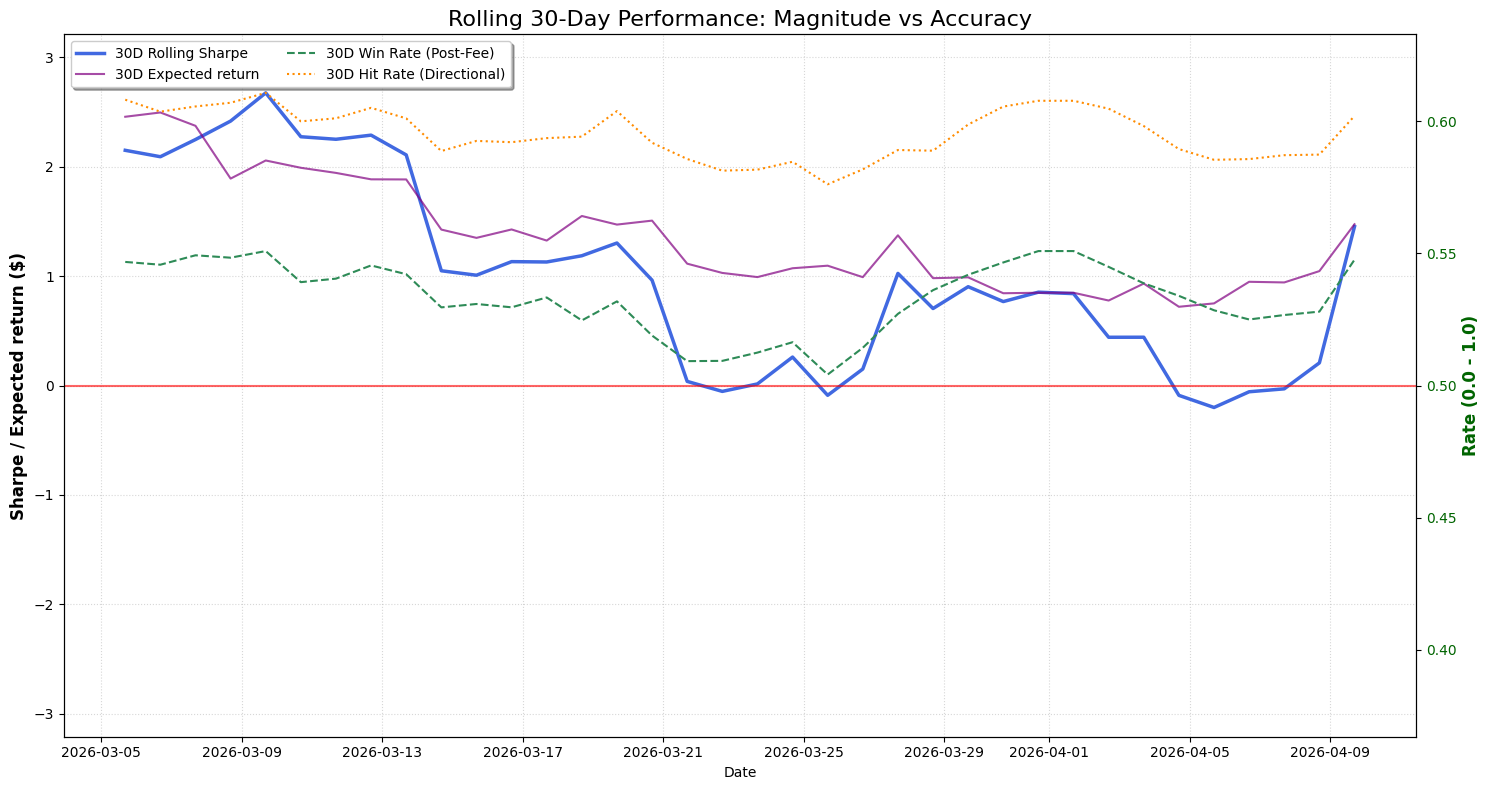

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Setup
df_15m['TIMESTAMP'] = pd.to_datetime(df_15m['TIMESTAMP'])
window_days = 30
current_start = df_15m['TIMESTAMP'].min()
end_date = df_15m['TIMESTAMP'].max()

# Lists to store our data
dates = []
sharpes = []
win_rates = []
hit_rates = []
win_losses = [] # <--- Added for Magnitude tracking

print("Starting rolling backtest...")

while current_start + pd.Timedelta(days=window_days) <= end_date:
    current_end = current_start + pd.Timedelta(days=window_days)

    df_window = df_15m[(df_15m['TIMESTAMP'] >= current_start) &
                       (df_15m['TIMESTAMP'] < current_end)]

    if not df_window.empty:
        # Run backtest
        res, stats = pro_backtest(df_window, min_confidence=0.8, pct_cost=5,
                                  strategy='long-short', leverage=1, print_results=False)

        dates.append(current_end)
        sharpes.append(stats['sharpe'])
        win_rates.append(stats['win_rate'])
        hit_rates.append(stats['hit_rate'])
        win_losses.append(stats['exp_value']) # <--- Collected from your dict

    current_start += pd.Timedelta(days=1)

# 2. Plotting the results
fig, ax1 = plt.subplots(figsize=(15, 8))

# Primary Axis: Sharpe Ratio & Win/Loss Ratio
color_sharpe = 'royalblue'
color_wl = 'purple'
ax1.set_xlabel('Date')
ax1.set_ylabel('Sharpe / Expected return ($)', fontsize=12, fontweight='bold')

line1 = ax1.plot(dates, sharpes, label='30D Rolling Sharpe', color=color_sharpe, linewidth=2.5)
line4 = ax1.plot(dates, win_losses, label='30D Expected return', color=color_wl, linewidth=1.5, alpha=0.7)

ax1.tick_params(axis='y')

# Secondary Axis: Win Rate & Hit Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Rate (0.0 - 1.0)', color='darkgreen', fontsize=12, fontweight='bold')

line2 = ax2.plot(dates, win_rates, label='30D Win Rate (Post-Fee)',
                 color='seagreen', linewidth=1.5, linestyle='--')
line3 = ax2.plot(dates, hit_rates, label='30D Hit Rate (Directional)',
                 color='darkorange', linewidth=1.5, linestyle=':')

ax2.tick_params(axis='y', labelcolor='darkgreen')

# --- ALIGNMENT LOGIC ---
# Adjust ax1 to fit both Sharpe and Win/Loss ratio
all_primary_vals = sharpes + win_losses
s_max = max(abs(min(all_primary_vals)), abs(max(all_primary_vals))) * 1.2
ax1.set_ylim(-s_max, s_max)

# Adjust ax2 for rates
max_dev = max(max(abs(pd.Series(win_rates) - 0.5)), max(abs(pd.Series(hit_rates) - 0.5))) * 1.2
ax2.set_ylim(0.5 - max_dev, 0.5 + max_dev)

# Middle Reference Line
ax1.axhline(0, color='red', linestyle='-', alpha=0.6, linewidth=1.5, label='Baseline (S=0 / Rate=0.5)')

# Formatting
plt.title('Rolling 30-Day Performance: Magnitude vs Accuracy', fontsize=16)
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# Combine legends
lines = line1 + line4 + line2 + line3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True, ncol=2)

plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

In [ ]:
#try the same strategy in different periods
unique_ts = sorted(df_15m['TIMESTAMP'].unique())
n = len(unique_ts)
s1 = int(n * 0.3)
s2 = int(n * 0.7)

df_part1 = df_15m[df_15m['TIMESTAMP'] <= unique_ts[s1]]
df_part2 = df_15m[(df_15m['TIMESTAMP'] > unique_ts[s1]) & (df_15m['TIMESTAMP'] <= unique_ts[s2])]
df_part3 = df_15m[df_15m['TIMESTAMP'] > unique_ts[s2]]

print(f"--- PHASE 1: {df_part1['TIMESTAMP'].min()} to {df_part1['TIMESTAMP'].max()} ---")
res1, stats1 = pro_backtest(df_part1, min_confidence=0.8, pct_cost=5, strategy='long-short', leverage=1)

print(f"\n--- PHASE 2: {df_part2['TIMESTAMP'].min()} to {df_part2['TIMESTAMP'].max()} ---")
res2, stats2 = pro_backtest(df_part2, min_confidence=0.8, pct_cost=5, strategy='long-short', leverage=1)

print(f"\n--- PHASE 3: {df_part3['TIMESTAMP'].min()} to {df_part3['TIMESTAMP'].max()} ---")
res3, stats3 = pro_backtest(df_part3, min_confidence=0.8, pct_cost=5, strategy='long-short', leverage=1)

--- PHASE 1: 2026-02-03 16:30:00 to 2026-02-23 18:30:00 ---
=== pro backtest [5m] ===
Total return: 3.77%
Sharpe ratio: 1.98
Max drawdown: 1.09%
Win rate:     57.58%
Exp return:   $2.05
Hit rate:     63.64%
Net gain:     $377.18
Total fees:   $339.81
Total trades: 90

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL ($)  Contribution (%)
AMZN    198.910600          1.989106
NFLX    129.398113          1.293981
TSLA     27.043826          0.270438
MSFT     -2.678770         -0.026788
META     -9.132010         -0.091320
AAPL    -13.432532         -0.134325
GOOGL   -17.825809         -0.178258
NVDA    -44.525539         -0.445255

Asset breadth: 3/8 assets were profitable!

--- PHASE 2: 2026-02-23 18:40:00 to 2026-03-19 16:40:00 ---
=== pro backtest [5m] ===
Total return: 2.03%
Sharpe ratio: 0.87
Max drawdown: 0.94%
Win rate:     51.32%
Exp return:   $1.54
Hit rate:     57.89%
Net gain:     $203.00
Total fees:   $422.35
Total trades: 120

--- ASSET BREAKDOWN (Net PnL) ---
       Net PnL 

In [ ]:
sharpe_1 = {}
sharpe_2 = {}
sharpe_3 = {}
for conf in [0, 0.2, 0.4, 0.6, 0.8]:
    for lev in [1, 5, 10]:
      for bips in [2,3,5]:
        res1, stats1 = pro_backtest(df_part1, min_confidence=conf, pct_cost=bips,
                                     strategy='long-short', leverage=lev, print_results=False)
        res2, stats2 = pro_backtest(df_part2, min_confidence=conf, pct_cost=bips,
                                     strategy='long-short', leverage=lev, print_results=False)
        res3, stats3 = pro_backtest(df_part3, min_confidence=conf, pct_cost=bips,
                                     strategy='long-short', leverage=lev, print_results=False)

        sharpe_1[(conf, lev, bips)] = stats1
        sharpe_2[(conf, lev, bips)] = stats2
        sharpe_3[(conf, lev, bips)] = stats3
print("--- PHASE 1: EARLY ---")
print(pd.DataFrame(sharpe_1).T)

print("\n--- PHASE 2: MIDDLE ---")
print(pd.DataFrame(sharpe_2).T)

print("\n--- PHASE 3: LATE ---")
print(pd.DataFrame(sharpe_3).T)

--- PHASE 1: EARLY ---
            sharpe  total_return       mdd  win_rate
0.0 1  2  3.112968      0.033528  0.007162  0.501844
       3  0.769454      0.016521  0.008011  0.490128
       5 -3.884817     -0.016661  0.022835  0.467130
    5  2  2.622620      0.106921  0.036687  0.497939
       3  0.278526      0.018802  0.048556  0.485789
       5 -4.368534     -0.136985  0.158923  0.463007
    10 2  2.008674      0.155763  0.074498  0.493599
       3 -0.335199     -0.020919  0.108687  0.479497
       5 -4.971423     -0.297500  0.328902  0.458451
0.2 1  2  2.974926      0.040073  0.009485  0.511069
       3  0.469268      0.015465  0.014047  0.499684
       5 -4.482582     -0.032022  0.041925  0.475965
    5  2  2.465225      0.133000  0.052937  0.507906
       3 -0.040028      0.005164  0.092440  0.493675
       5 -4.980938     -0.208928  0.242906  0.470272
    10 2  1.827210      0.186111  0.121391  0.501265
       3 -0.676374     -0.066462  0.203389  0.488931
       5 -5.601410     

In [ ]:
rows = []

for (conf, lev, bips), stats in sharpe_1.items():
    rows.append({
        "confidence": conf,
        "leverage": lev,
        "cost": bips,
        "sharpe": stats["sharpe"],
        "return": stats["total_return"],
        "phase": "early"
    })

for (conf, lev, bips), stats in sharpe_2.items():
    rows.append({
        "confidence": conf,
        "leverage": lev,
        "cost": bips,
        "sharpe": stats["sharpe"],
        "return": stats["total_return"],
        "phase": "middle"
    })

for (conf, lev, bips), stats in sharpe_3.items():
    rows.append({
        "confidence": conf,
        "leverage": lev,
        "cost": bips,
        "sharpe": stats["sharpe"],
        "return": stats["total_return"],
        "phase": "late"
    })

sharpe_all = pd.DataFrame(rows)

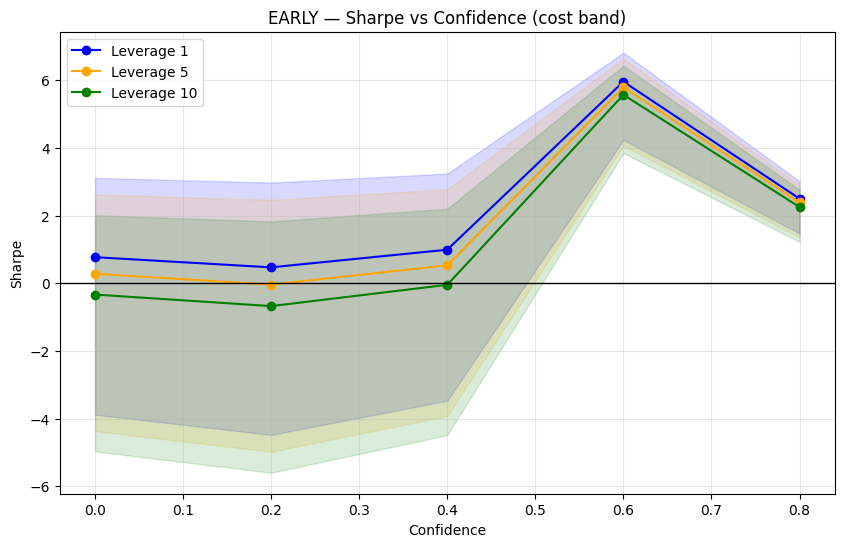

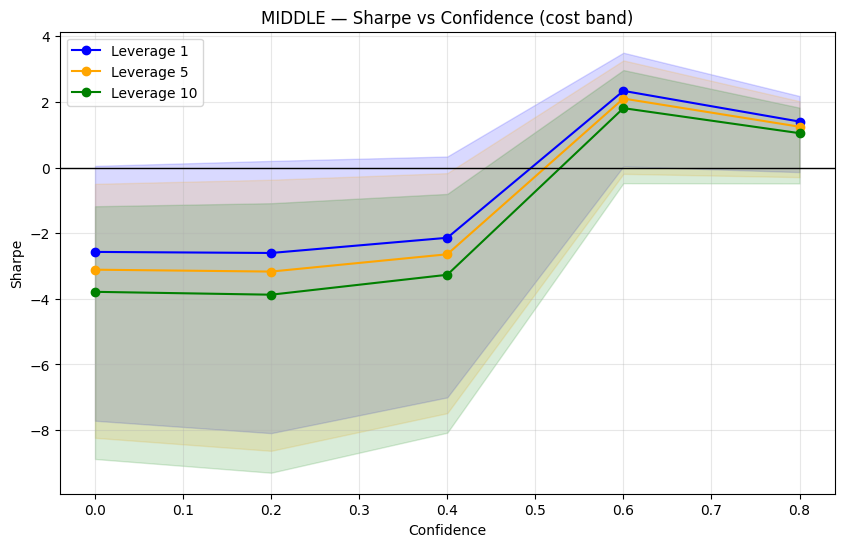

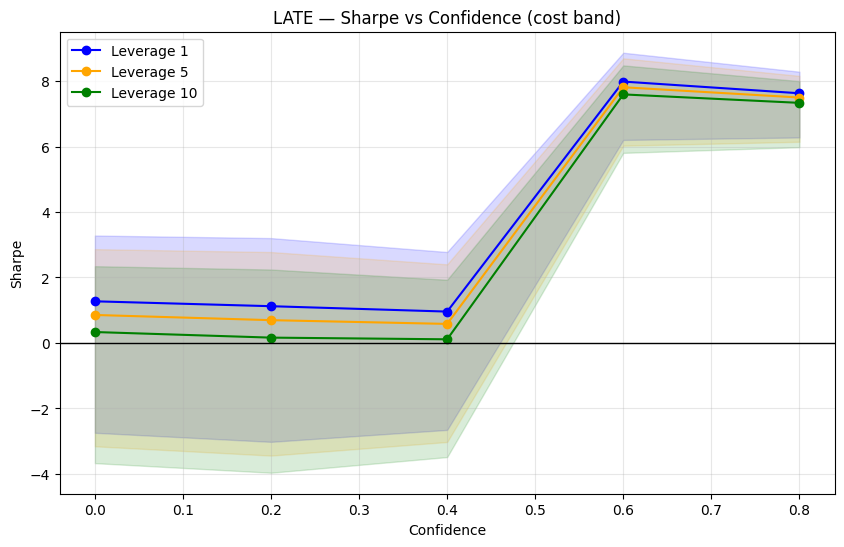

In [ ]:
import matplotlib.pyplot as plt

def plot_sharpe(df, phase="early"):
    subset = df[df["phase"] == phase]

    plt.figure(figsize=(10,6))

    colors = {1: "blue", 5: "orange", 10: "green"}

    for lev in sorted(subset["leverage"].unique()):
        data = subset[subset["leverage"] == lev]

        pivot = data.pivot_table(
            index="confidence",
            columns="cost",
            values="sharpe",
            aggfunc="mean"
        ).sort_index()

        x = pivot.index
        y_mid = pivot[3]   # baseline
        y_low = pivot[5]   # worst cost
        y_high = pivot[2]  # best cost

        color = colors.get(lev, None)

        # cost band (same color, light transparency)
        plt.fill_between(
            x, y_low, y_high,
            color=color,
            alpha=0.15
        )

        # main line (3 bps)
        plt.plot(
            x, y_mid,
            marker="o",
            color=color,
            label=f"Leverage {lev}"
        )

    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{phase.upper()} — Sharpe vs Confidence (cost band)")
    plt.xlabel("Confidence")
    plt.ylabel("Sharpe")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_sharpe(sharpe_all, "early")
plot_sharpe(sharpe_all, "middle")
plot_sharpe(sharpe_all, "late")

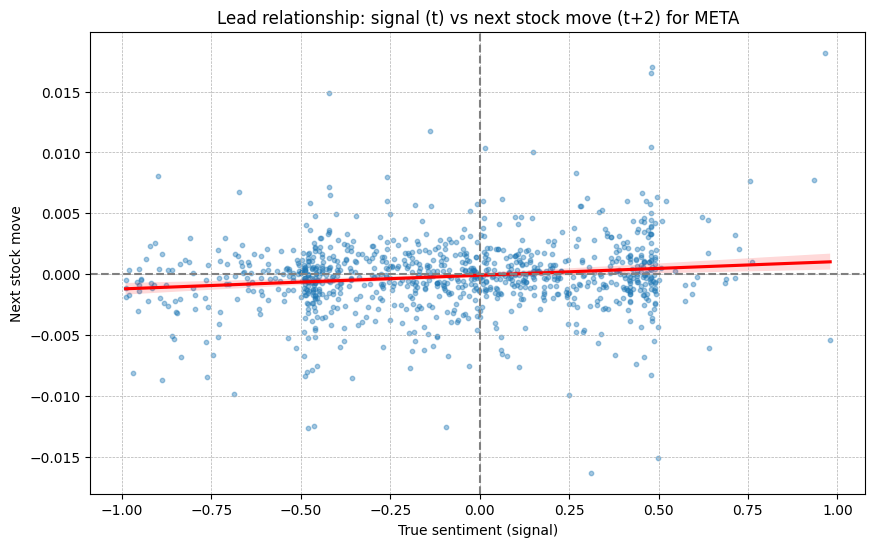

In [ ]:
#from here onwards gpt graphs
import seaborn as sns
import matplotlib.pyplot as plt

def plot_signal_vs_move(df, asset='TSLA'):
    sub = df[(df['KEY'] == asset) & (df['time_to_exp'] > 2)].copy()
    sub = sub.replace([np.inf, -np.inf], np.nan).dropna(subset=['true_sentiment', 'next_stock_move'])

    plt.figure(figsize=(10, 6))
    sns.regplot(
        x='true_sentiment',
        y='next_stock_move',
        data=sub,
        scatter_kws={'alpha': 0.4, 's': 10},
        line_kws={'color': 'red'})
    plt.axhline(0, color='grey', linestyle='--')
    plt.axvline(0, color='grey', linestyle='--')
    plt.title(f'Lead relationship: signal (t) vs next stock move (t+2) for {asset}')
    plt.xlabel('True sentiment (signal)')
    plt.ylabel('Next stock move')
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

plot_signal_vs_move(df_15m, asset='META')

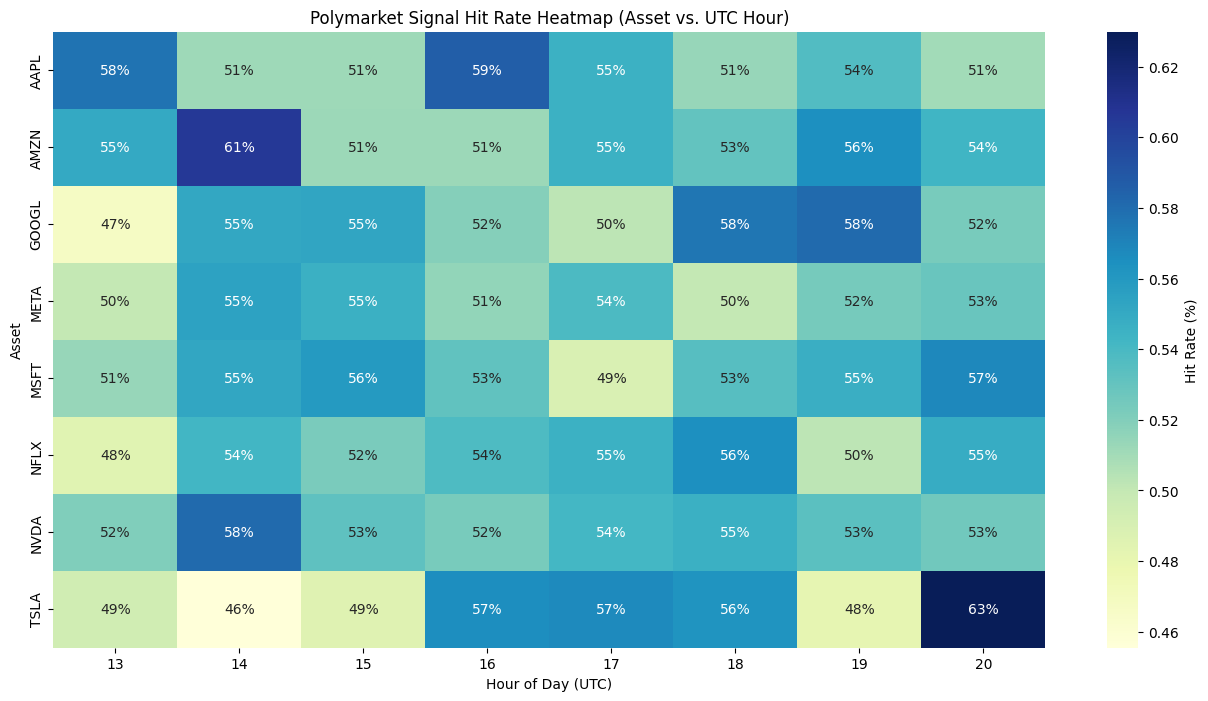

In [ ]:
def plot_hit_rate_heatmap(df):
    # Prepare data: calculate hit rate by asset and hour
    df['hour_utc'] = pd.to_datetime(df['TIMESTAMP']).dt.hour

    # We only care about signals with some conviction
    df = df[df['abs_sentiment'] > 0.05].copy()
    df['is_hit'] = (np.sign(df['true_sentiment']) == np.sign(df['next_stock_move'])).astype(int)

    heatmap_data = df.groupby(['KEY', 'hour_utc'])['is_hit'].mean().unstack()

    plt.figure(figsize=(16, 8))
    sns.heatmap(
        heatmap_data,
        cmap='YlGnBu', # Yellow -> Green -> Blue (bright green = high hit rate)
        annot=True,     # Show values
        fmt=".0%",      # Format as percentage
        cbar_kws={'label': 'Hit Rate (%)'}
    )
    plt.title('Polymarket Signal Hit Rate Heatmap (Asset vs. UTC Hour)')
    plt.xlabel('Hour of Day (UTC)')
    plt.ylabel('Asset')
    plt.show()

plot_hit_rate_heatmap(df_15m)